<a href="https://colab.research.google.com/github/Oladahmad/FInal_year_projects/blob/main/DDOS_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
df = pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

df.head(10)
df.shape

(81123, 85)

In [ ]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
df = df.drop_duplicates()

df.shape

(81105, 85)

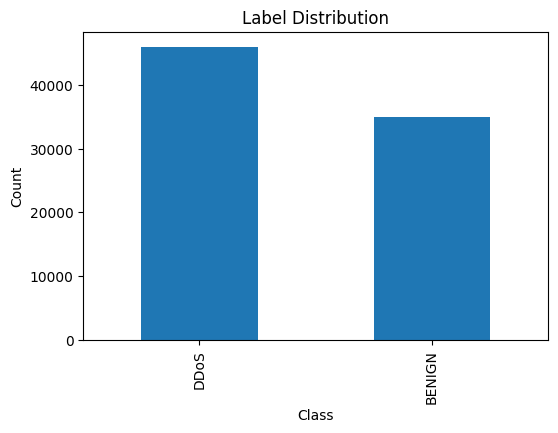

In [ ]:
label_counts = df['Label'].value_counts()

label_counts

plt.figure(figsize=(6,4))
label_counts.plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.savefig(os.path.join(output_dir, "label_distribution.png"))
plt.show()

In [ ]:
encoder = LabelEncoder()
df['Label'] = encoder.fit_transform(df['Label'])

df['Label'].value_counts()

,count
Label,
1,46059
0,35046


In [ ]:
drop_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df.shape

(81105, 81)

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

numeric_df.shape

(81105, 81)

In [ ]:
numeric_df.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
Source Port,81105.0,3.683187e+04,2.265396e+04,0.0,17310.0,50308.0,56918.0,65534.0
Destination Port,81105.0,6.888920e+03,1.735850e+04,0.0,80.0,80.0,80.0,62141.0
Protocol,81105.0,7.777128e+00,4.051615e+00,0.0,6.0,6.0,6.0,17.0
Flow Duration,81105.0,1.494036e+07,2.891904e+07,1.0,60069.0,1245856.0,8164100.0,119999439.0
Total Fwd Packets,81105.0,4.997497e+00,1.530847e+01,1.0,2.0,3.0,5.0,1681.0


In [ ]:
skewness = numeric_df.skew()
kurtosis = numeric_df.kurtosis()

skewness.to_csv(os.path.join(output_dir, "skewness.csv"))
kurtosis.to_csv(os.path.join(output_dir, "kurtosis.csv"))

skewness.head(20)
kurtosis.head(20)

,0
Source Port,-1.419441
Destination Port,3.829725
Protocol,1.376132
Flow Duration,2.391528
Total Fwd Packets,4391.765073
Total Backward Packets,5692.382937
Total Length of Fwd Packets,340.645628
Total Length of Bwd Packets,5591.955733
Fwd Packet Length Max,27.343403
Fwd Packet Length Min,72.371183


In [ ]:
variance = numeric_df.var()
low_var = variance[variance < 0.01].index.tolist()

numeric_df = numeric_df.drop(columns=low_var)

len(low_var)

13

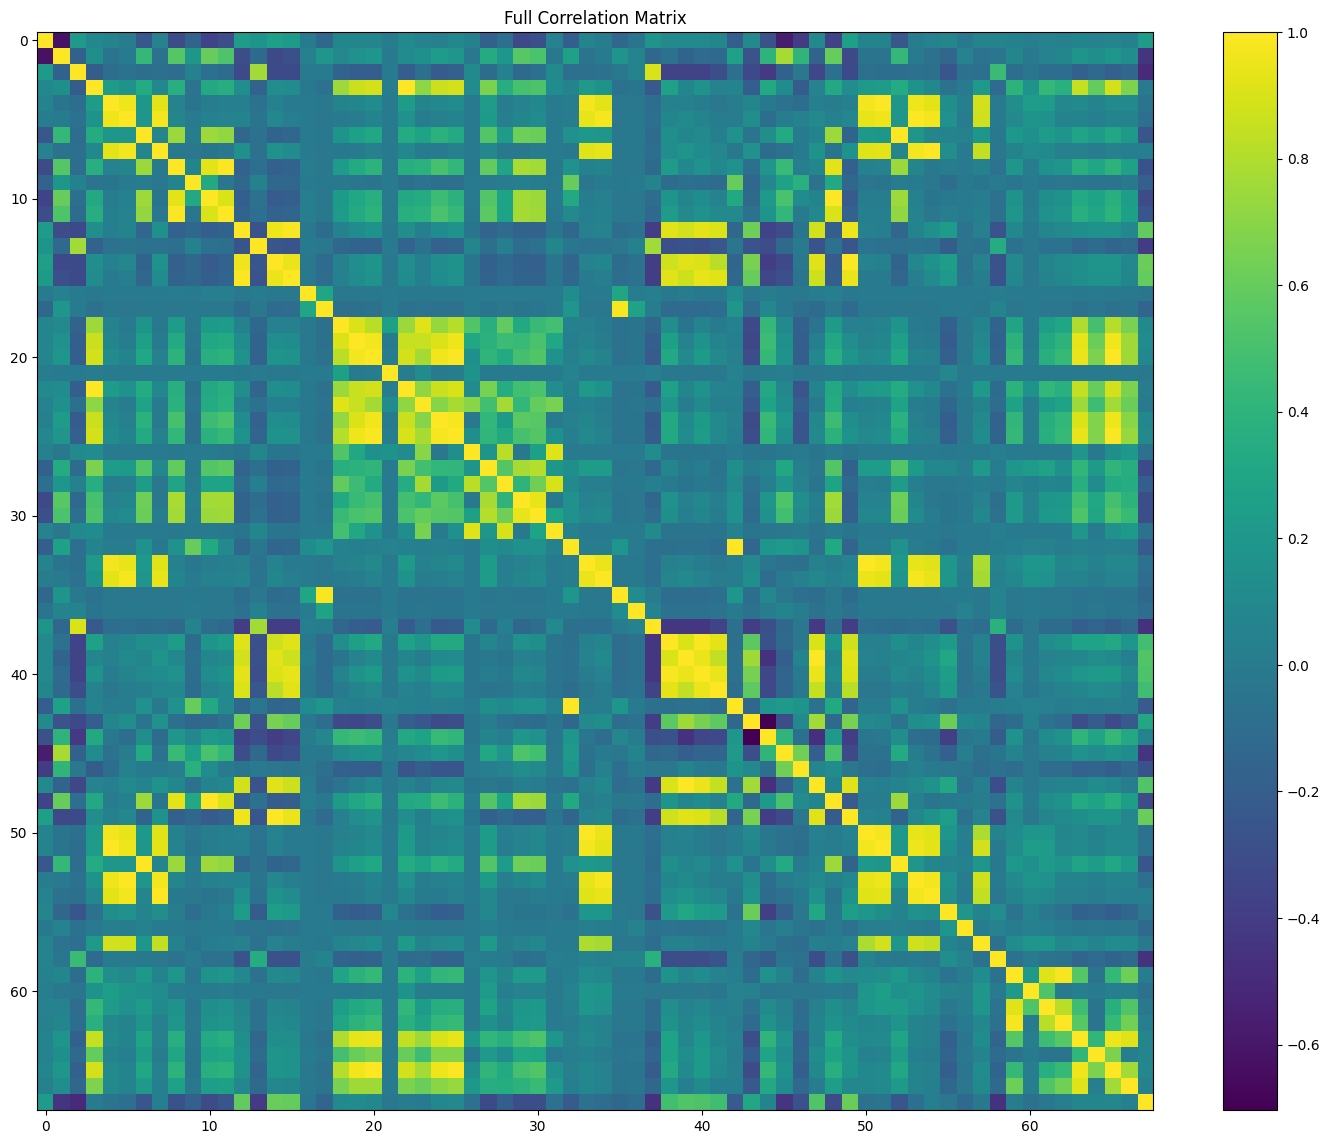

In [ ]:
corr_matrix = numeric_df.corr()

plt.figure(figsize=(18,14))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.title("Full Correlation Matrix")
plt.savefig(os.path.join(output_dir, "full_corr.png"))
plt.show()

In [ ]:
corr_target = corr_matrix['Label'].abs().sort_values(ascending=False)

top_features = corr_target.head(20).index.tolist()

corr_target.head(20)

,Label
Label,1.000000
Bwd Packet Length Mean,0.619669
Avg Bwd Segment Size,0.619669
Bwd Packet Length Std,0.594184
Bwd Packet Length Max,0.593354
Average Packet Size,0.536610
Packet Length Mean,0.536123
Packet Length Std,0.522641
Protocol,0.502842
Max Packet Length,0.486434


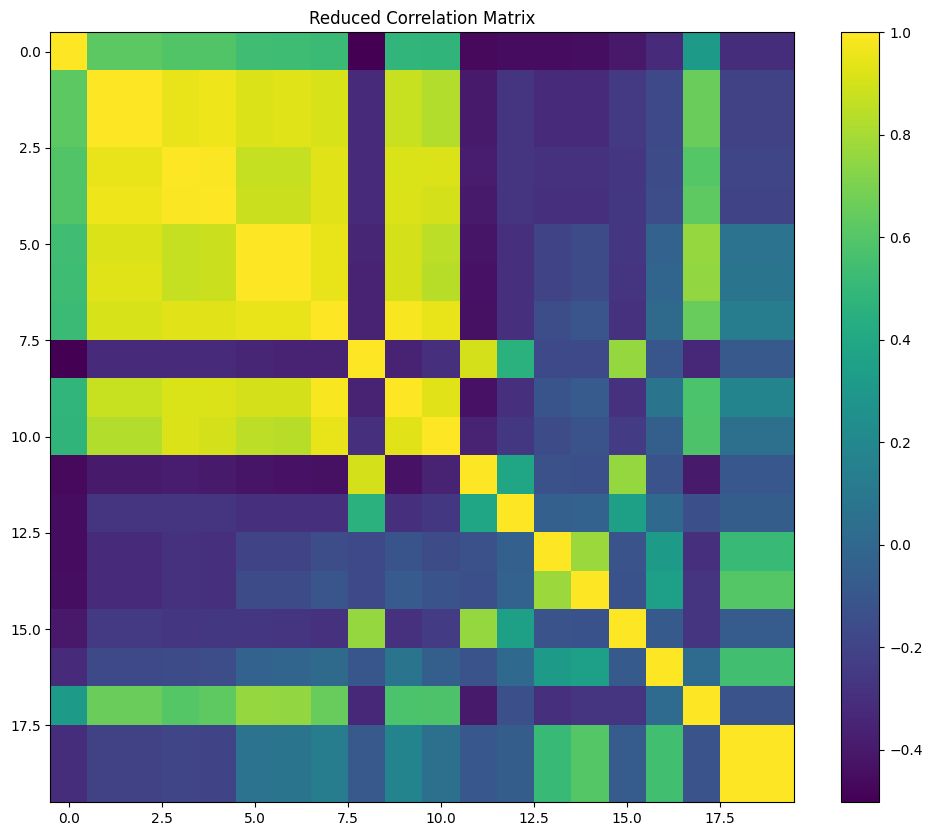

In [ ]:
reduced_df = numeric_df[top_features]
reduced_corr = reduced_df.corr()

plt.figure(figsize=(12,10))
plt.imshow(reduced_corr, aspect='auto')
plt.colorbar()
plt.title("Reduced Correlation Matrix")
plt.savefig(os.path.join(output_dir, "reduced_corr.png"))
plt.show()

In [ ]:
means = reduced_df.mean()
std_dev = reduced_df.std()

means.head()
std_dev.head()

print("Mean: \n", means)
print("Standard deviation: \n", std_dev)

Mean: 
 Label                     5.678935e-01
Bwd Packet Length Mean    9.398679e+02
Avg Bwd Segment Size      9.398679e+02
Bwd Packet Length Std     1.288101e+03
Bwd Packet Length Max     2.876110e+03
Average Packet Size       5.784672e+02
Packet Length Mean        5.184904e+02
Packet Length Std         1.080329e+03
Protocol                  7.777128e+00
Max Packet Length         3.201618e+03
Packet Length Variance    2.765746e+06
Min Packet Length         8.585007e+00
min_seg_size_forward      2.180132e+01
URG Flag Count            1.337279e-01
Destination Port          6.888920e+03
Bwd Packet Length Min     1.842143e+01
Bwd IAT Total             6.453596e+06
PSH Flag Count            3.615560e-01
Avg Fwd Segment Size      1.215155e+02
Fwd Packet Length Mean    1.215155e+02
dtype: float64
Standard deviation: 
 Label                     4.953721e-01
Bwd Packet Length Mean    1.124671e+03
Avg Bwd Segment Size      1.124671e+03
Bwd Packet Length Std     1.742452e+03
Bwd Packet Length M

<Figure size 1200x800 with 0 Axes>

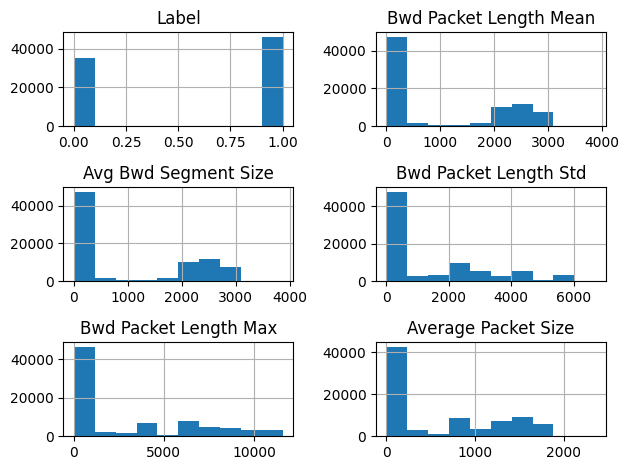

In [ ]:
sample = reduced_df.iloc[:, :6]

plt.figure(figsize=(12,8))
sample.hist()
plt.tight_layout()
plt.show()

In [ ]:
low_q = reduced_df.quantile(0.01)
high_q = reduced_df.quantile(0.99)

reduced_df = reduced_df.clip(low_q, high_q, axis=1)

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(reduced_df)

scaled_df = pd.DataFrame(scaled_data, columns=reduced_df.columns)

scaled_df.head()

,Label,Bwd Packet Length Mean,Avg Bwd Segment Size,Bwd Packet Length Std,Bwd Packet Length Max,Average Packet Size,Packet Length Mean,Packet Length Std,Protocol,Max Packet Length,Packet Length Variance,Min Packet Length,min_seg_size_forward,URG Flag Count,Destination Port,Bwd Packet Length Min,Bwd IAT Total,PSH Flag Count,Avg Fwd Segment Size,Fwd Packet Length Mean
0,0.0,0.000000,0.000000,0.0,0.000000,0.005416,0.004126,0.0,0.0,0.000517,0.0,0.101695,0.0,0.0,0.919387,0.000000,0.0,0.0,0.002585,0.002585
1,0.0,0.002068,0.002068,0.0,0.000517,0.005416,0.004126,0.0,0.0,0.000517,0.0,0.101695,0.0,1.0,0.922558,0.031088,0.0,0.0,0.002585,0.002585
2,0.0,0.002068,0.002068,0.0,0.000517,0.005416,0.004126,0.0,0.0,0.000517,0.0,0.101695,0.0,1.0,0.922574,0.031088,0.0,0.0,0.002585,0.002585
3,0.0,0.002068,0.002068,0.0,0.000517,0.005416,0.004126,0.0,0.0,0.000517,0.0,0.101695,0.0,1.0,0.774649,0.031088,0.0,0.0,0.002585,0.002585
4,0.0,0.000000,0.000000,0.0,0.000000,0.005416,0.004126,0.0,0.0,0.000517,0.0,0.101695,0.0,0.0,0.919354,0.000000,0.0,0.0,0.002585,0.002585


In [ ]:
scaled_df.min().head()
scaled_df.max().head()

,0
Label,1.0
Bwd Packet Length Mean,1.0
Avg Bwd Segment Size,1.0
Bwd Packet Length Std,1.0
Bwd Packet Length Max,1.0


In [ ]:
X = scaled_df.drop('Label', axis=1)
y = scaled_df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((56773, 19), (24332, 19))

In [ ]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

,proportion
Label,
1.0,0.567894
0.0,0.432106


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
model = Sequential()

# input layer + first hidden layer
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))

# second hidden layer
model.add(Dense(32, activation='relu'))

# dropout to reduce overfitting
model.add(Dropout(0.3))

# third hidden layer
model.add(Dense(16, activation='relu'))

# output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9770 - loss: 0.0887 - val_accuracy: 0.9843 - val_loss: 0.0526
Epoch 2/20
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0462 - val_accuracy: 0.9965 - val_loss: 0.0268
Epoch 3/20
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9936 - loss: 0.0273 - val_accuracy: 0.9961 - val_loss: 0.0187
Epoch 4/20
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9952 - loss: 0.0241 - val_accuracy: 0.9966 - val_loss: 0.0177
Epoch 5/20
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9955 - loss: 0.0221 - val_accuracy: 0.9966 - val_loss: 0.0180
Epoch 6/20
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9954 - loss: 0.0221 - val_accuracy: 0.9966 - val_loss: 0.0175
Epoch 7/20
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9954 - loss: 0.0221 - val_accuracy: 0.9966 - val_loss: 0.0173
Epoch 8/20
1420/1420 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9955 - loss: 0.0217 -

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

761/761 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9952 - loss: 0.0210
Test Accuracy: 0.9951504468917847
Test Loss: 0.020995404571294785


In [ ]:
y_pred_prob = model.predict(X_test)

# convert probabilities to binary values
y_pred = (y_pred_prob > 0.5).astype(int)

761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     10514
         1.0       0.99      1.00      1.00     13818

    accuracy                           1.00     24332
   macro avg       1.00      0.99      1.00     24332
weighted avg       1.00      1.00      1.00     24332



array([[10396,   118],
       [    0, 13818]])

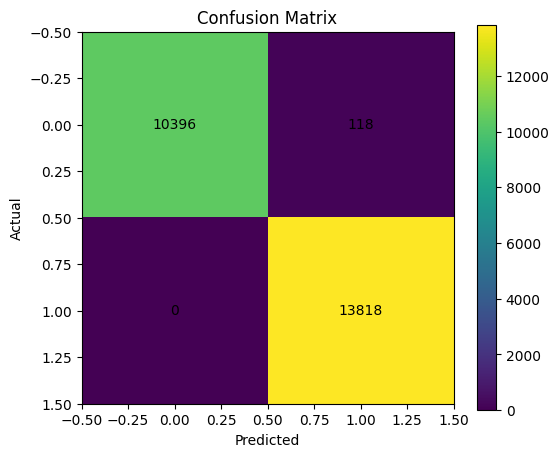

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

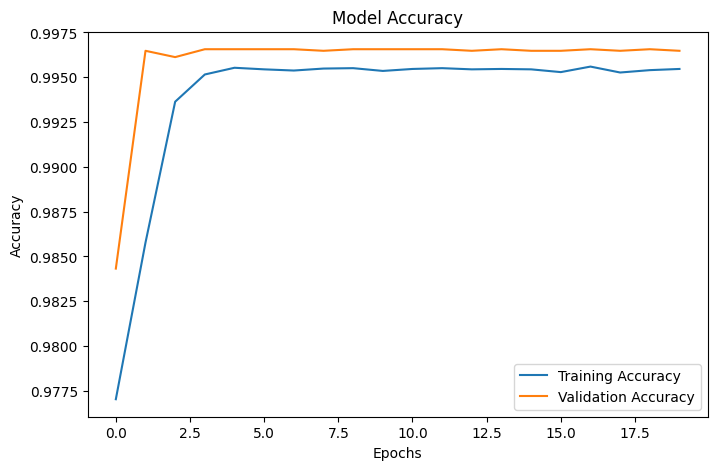

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

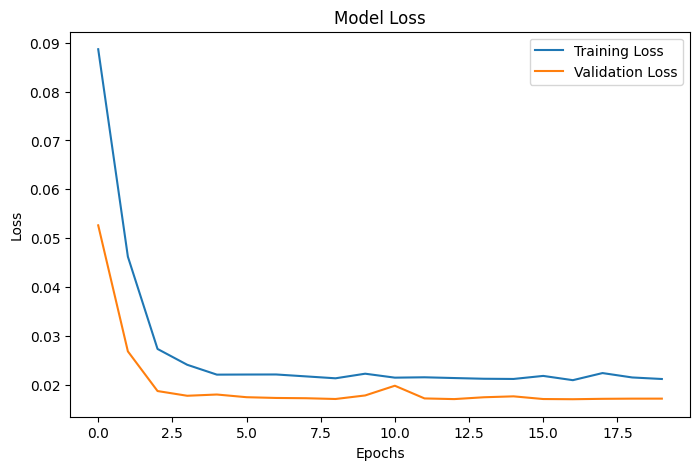

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig(os.path.join(output_dir, "loss_plot.png"))
plt.show()